# Modelo de Barabasi-Albert

Las redes reales no tienen una cantidad fija de nodos, van creciendo con el tiempo. Cuando un nuevo nodo aparece, se conecta con algunos de los ya existentes. La pregunta es, ¿a cuáles nodos es más probable que se conecte el nuevo nodo?

## El modelo de Price

El modelo de Price es para redes dirigidas, usualmente redes de información:

- En la red de citas, un nuevo artículo es más probable que cite a los artículos que tengan una mayor cantidad de citas que a los que tienen pocas citas.
- En la red www, es más probable visitar una página que tenga enlaces desde muchas otras páginas (grado de entrada) que las que tengas pocos.
- En la red de actores (caso no dirigido), es más probable que un director de película se fije en un actor o tenga más referencia de un actor que ha participado en muchas películas que otro que haya participado en pocas.

Es más probable que un nuevo nodo en la red conecte con nodos con mayor grado de entrada (en el caso dirigido). Es decir, la probabilidad de que un nodo $i$ de la red sea "seguido" por el nuevo nodo, es proporcional al grado de entrada, $q_i$, del nodo $i$. Sin embargo, si $j$ es el nuevo nodo, su grado de entrada inicial es cero, por lo que la probabilidad de que sea seguido por nuevos nodos sería cero.

Una manera de resolver este problema, es asignar una probabilidad inicial "de a gratis". Entonces, al agregar un nuevo nodo, la probabilidad de que éste apunte a un nodo nodo particular $i$ es proporcional a $q_i+a$, donde $a$ es una constante positiva; es decir:

$$\frac{q_i+a}{\sum_j(q_j+a)}$$

En este cuaderno de trabajo, analizaremos el caso no dirigido.

## Modelo de Barabasi-Albert

En el caso no dirigido, al agregar un nuevo nodo, éste se conecta con $m$ de los nodos ya existentes. Por lo que su grado inicial es $m\neq 0$. No es necesario añadir una constante. Así que la probabilidad de que un nodo $i$ sea conectado con el nuevo nodo, es proporcional a su grado $k_i$:

$$\Pi(k_i)=\frac{k_i}{\sum_jk_j}$$

### Apego preferencial

Es un mecanismo probabilístico: un nuevo nodo es libre de conectarse con cualquier nodo de la red, ya sea importante o no. Sin embargo, si el nuevo nodo tiene la opción entre un nodo de grado dos y uno de grado cuatro, es doblemente probable que se conecte al nodo de grado cuatro que al nodo de grado dos.

### El modelo

Comenzamos con una red inicial $G$ con $m_0$ nodos, preferentemente conexa. En cada paso agregamos un nuevo nodo con $m$ ($\leq m_0$) aristas que conectan al nuevo nodo con $m$ nodos ya existentes en la red.

Desmués de $t$ pasos, el modelo de Barabasi-Albert genera una nueva red con $n=t+m_0$ nodos y $mt$ nuevas aristas.

#### El caso $m=1$

Analicemos el caso en que el nuevo nodo se conecta con un nodo de la red. Construyamos una red inicial $G$:

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

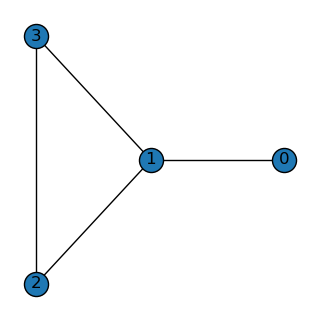

In [2]:
G = nx.Graph()

G.add_nodes_from([0,3,1,2])
G.add_edges_from([(0,1),(1,3),(2,3),(2,1)]) # Agregamos nodos y aristas de manera que nos quede una red conexa

plt.figure(figsize=[3,3])
nx.draw_kamada_kawai(G, with_labels=True, edgecolors='k')

Agreguemos un nodo y conectémoslo a uno ya existente.

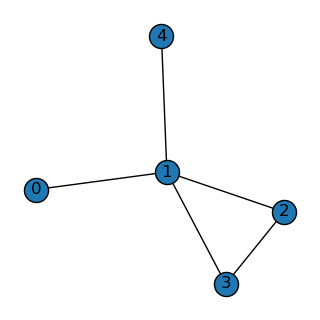

In [3]:
P = np.array([G.degree(nodo) for nodo in G])
P = P/P.sum() # Se calcula la probabilidad de que un nodo viejo sea conectado con el nuevo nodo

nuevo_nodo = len(G) #Definimos el nuevo nodo
viejo_nodo = np.random.choice(G, replace = False, p = P) #Se selecciona el nodo a conectar
G.add_edge(nuevo_nodo,viejo_nodo) #Se conectan los nodos nuevo y viejo
plt.figure(figsize=[3,3])
nx.draw(G, with_labels=True, edgecolors='k')

Volviendo a correr la celda, podemos ver cómo se va construyendo la red, cómo los nuevos nodos se van uniendo. Con el siguiente código, podemos ir viendo cómo cambia la distribución de grados de la red. Ponemos el tamaño de los nodos proporcional a su grado y pintamos el nuevo nodo de rojo.

(0.5, 5.5)

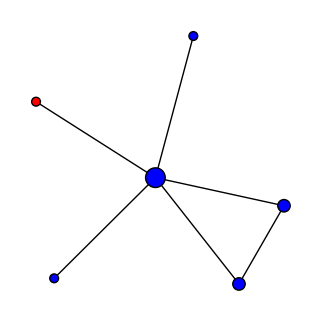

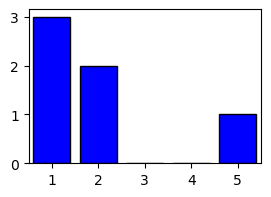

In [4]:
P = np.array([G.degree(nodo) for nodo in G])
P = P/P.sum() # Se calcula la probabilidad de que un nodo viejo sea conectado con el nuevo nodo

nuevo_nodo = len(G) #Definimos el nuevo nodo
viejo_nodo = np.random.choice(G, replace = False, p = P) #Se selecciona el nodo a conectar
G.add_edge(nuevo_nodo,viejo_nodo) #Se conectan los nodos nuevo y viejo

colores = ['b' for nodo in G] #Construimos una cadena de colores azules para todos los nodos
colores[-1]='r' #Redefinimos el color el último nodo como rojo

grados = [G.degree(nodo) for nodo in G]
grados = np.array(grados) #Hacemos un arreglo de grados para 

plt.figure(figsize=[3,3])
nx.draw(G, edgecolors='k', node_color=colores, node_size=200*grados/grados.max()) #Normalizamos el tamaño de los nodos


y, x = np.histogram(grados, bins = range(max(grados)+2))

plt.figure(figsize = [3,2])
plt.bar(x[:-1], y, color = 'blue', edgecolor='k')
plt.xlim([.5,max(grados)+.5])

Podemos ver cómo va cambiando la red y la distribución de grados en cada paso. Podemos observar que los nodos con mayor grado tienden a tener más conexiones. Con el siguiente ciclo for podemos analizar la red después de una cantidad de pasos grande.

(0.5, 110.5)

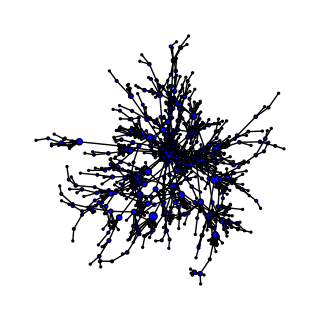

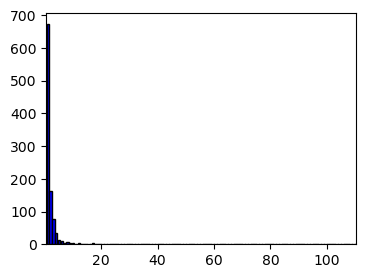

In [5]:
t=1000
for i in range(t):
    P = np.array([G.degree(nodo) for nodo in G])
    P = P/P.sum() # Se calcula la probabilidad de que un nodo viejo sea conectado con el nuevo nodo

    nuevo_nodo = len(G) #Definimos el nuevo nodo
    viejo_nodo = np.random.choice(G, replace = False, p = P) #Se selecciona el nodo a conectar
    G.add_edge(nuevo_nodo,viejo_nodo) #Se conectan los nodos nuevo y viejo

colores = ['b' for nodo in G] #Construimos una cadena de colores azules para todos los nodos
colores[-1]='r' #Redefinimos el color el último nodo como rojo

grados = [G.degree(nodo) for nodo in G]
grados = np.array(grados) #Hacemos un arreglo de grados para 

plt.figure(figsize=[3,3])
nx.draw(G, edgecolors='k', node_color=colores, node_size=200*grados/grados.max()) #Normalizamos el tamaño de los nodos


y, x = np.histogram(grados, bins = range(max(grados)+2))

plt.figure(figsize = [4,3])
plt.bar(x[:-1], y, color = 'blue', edgecolor='k')
plt.xlim([.5,max(grados)+.5])

Después de iterar una cantidad grande de veces, ¿la distribución de grados sigue una ley de potencias?
$$p_k=Ck^{-\alpha}$$
¿Cuál sería el valor de $\alpha$?

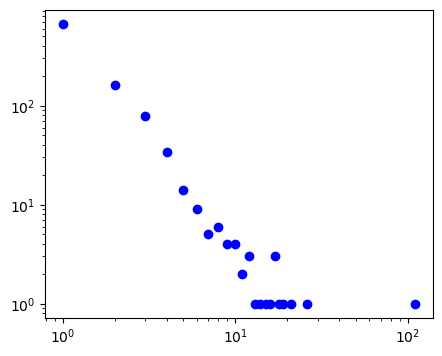

In [6]:
plt.figure(figsize = [5,4])
plt.loglog(x[:-1], y, 'o', color = 'blue')

In [7]:
saltos = []

for i in range(len(y)-1):
    if y[i+1] == 0 or y[i]==0 or y[i+1] == 1 :
        saltos.append(0)
    else:
        saltos.append(np.log(y[i]) / np.log(y[i+1]))
        print(y[i], y[i+1], np.log(y[i]) / np.log(y[i+1]))

672 163 1.278087476588867
163 78 1.1691738886936829
78 34 1.2354689193793684
34 14 1.3362197497734014
14 9 1.2010867513664396
9 5 1.3652123889719707
5 6 0.8982444017039272
6 4 1.292481250360578
4 4 1.0
4 2 2.0
2 3 0.6309297535714574
1 3 0.0


In [8]:

grados = np.array([G.degree(nodo) for nodo in G])

k_vals, n_k = np.unique(grados, return_counts=True)
p_k = n_k / n_k.sum()

#    log P(K=k) = log C - alpha log k

tail = k_vals >= 1

log_k = np.log(k_vals[tail])
log_p = np.log(p_k[tail])

pendiente, intercepto = np.polyfit(log_k, log_p, 1)

alpha_hat = -pendiente
C_hat = np.exp(intercepto)

print(f"Estimación de alpha: {alpha_hat:.4f}")
print(f"Estimación de C: {C_hat:.4f}")


Estimación de alpha: 1.7233
Estimación de C: 0.2339


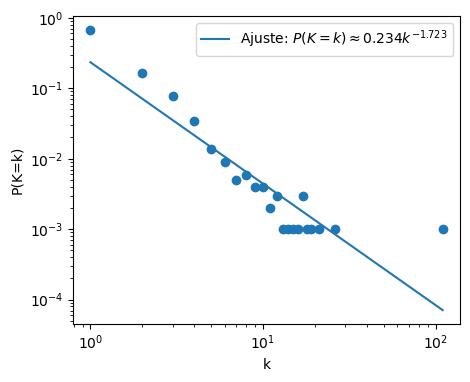

In [9]:
plt.figure(figsize=(5, 4))
plt.scatter(k_vals[tail], p_k[tail])
plt.plot(
    k_vals[tail],
    C_hat * k_vals[tail] ** (-alpha_hat),
    label=fr'Ajuste: $P(K=k)\approx {C_hat:.3f}k^{{-{alpha_hat:.3f}}}$'
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('k')
plt.ylabel('P(K=k)')
plt.legend()
plt.show()

*En el caso no dirigido, al agregar un nuevo nodo, éste se conecta con $m$ de los nodos ya existentes. Por lo que su grado inicial es $m\neq 0$. No es necesario añadir una constante. Así que la probabilidad de que un nodo $i$ sea conectado con el nuevo nodo, es proporcional a su grado $k_i$:*

$$\Pi(k_i)=\frac{k_i}{\sum_jk_j}$$

*La suma ${\sum_jk_j}$ al tiempo $t$ en Barabasi-Albert genera una nueva red con $n=t+m_0$ nodos y $mt$ nuevas aristas.*




















En cada paso se agrega un nuevo nodo y éste se conecta con exactamente $m$ nodos ya existentes. Por tanto, el grado inicial de cada nodo nuevo es

$$  
k_i(t_i)=m,  
$$

donde $t_i$ es el instante en que nace el nodo $i$.

Por ello,

$$  
\Pi_i(t)=\frac{k_i(t)}{\sum_j k_j(t)}.  
$$


Como es no dirigido, la suma de todos los grados es el doble del número de aristas:

$$  
\sum_j k_j(t)=2E(t).  
$$

En cada paso se agregan exactamente $m$ aristas, así que si $E_0$ es el número inicial de aristas, entonces

$$  
E(t)=E_0+mt.  
$$

Nos interesa saber cuando $t$ grande, el término inicial $E_0$ se vuelve despreciable frente a $mt$, y por ello

$$  
\sum_j k_j(t)=2E(t)=2(E_0+mt)\approx 2mt.  
$$

Sustituyendo esto en la expresión de $\Pi_i(t)$, se obtiene

$$  
\Pi_i(t)\approx \frac{k_i(t)}{2mt}.  
$$


En cada paso llegan $m$ aristas nuevas. Cada una de ellas tiene probabilidad $\Pi_i(t)$ de conectarse al nodo $i$. Por tanto, el número esperado de nuevas conexiones que recibe el nodo $i$ en ese paso es aproximadamente


$$  
m\Pi_i(t).  
$$

Representa el incremento esperado del grado del nodo $i$. En tiempo discreto esto se escribiría como

$$  
k_i(t+1)-k_i(t)\approx m\Pi_i(t).  
$$

Después, para facilitar el cálculo, se usa una aproximación continua y se reemplaza esta diferencia por una derivada:

$$  
\frac{dk_i}{dt}\approx m\Pi_i(t).  
$$

Así, sustituyendo la expresión anterior de $\Pi_i(t)$, resulta

$$  
\frac{dk_i}{dt}=m\cdot\frac{k_i(t)}{2mt}=\frac{k_i(t)}{2t}.  
$$

Esta ecuación diferencial dice que la tasa de cambio del grado respecto al tiempo es proporcional al propio grado y decrece como $1/t$. 

$$  
\frac{dk_i}{dt}=\frac{k_i(t)}{2t}.  
$$

$$  
	\frac{dk_i}{k_i}=\frac{dt}{2t}.  
$$

$$  
\int \frac{dk_i}{k_i}=\int \frac{dt}{2t}.  
$$
$$  
\ln k_i=\frac{1}{2}\ln t+C,  
$$

donde $C$ es una constante de integración. Al exponentiar ambos lados, resulta

$$  
k_i(t)=Ct^{1/2}.  
$$

Usando la condición inicial $k_i(t_i)=m$, se obtiene

$$  
m=Ct_i^{1/2},  
$$

de donde

$$  
C=\frac{m}{t_i^{1/2}}.  
$$

Así,

$$  
k_i(t)=m\left(\frac{t}{t_i}\right)^{1/2}.  
$$

Esto muestra que los nodos más antiguos tienden a tener mayor grado, porque si $t_i$ es pequeño, entonces el cociente $t/t_i$ es grande.

Ahora queremos encontrar la distribución de grados. Para que un nodo tenga grado al menos $k$, debe cumplirse

$$  
k_i(t)\ge k.  
$$

Sustituyendo la expresión anterior,

$$  
m\left(\frac{t}{t_i}\right)^{1/2}\ge k.  
$$

Despejando $t_i$,

$$  
t_i\le \frac{m^2t}{k^2}.  
$$

Esto significa que un nodo tendrá grado al menos $k$ si nació suficientemente temprano. Como en cada instante nace exactamente un nodo, los tiempos de nacimiento de los nodos presentes en el tiempo $t$ están aproximadamente distribuidos de manera uniforme entre $1$ y $t$. Por ello, la proporción de nodos que nacieron antes de $\frac{m^2t}{k^2}$ es aproximadamente

$$  
\Pr(K\ge k)\approx \frac{m^2t/k^2}{t}=\frac{m^2}{k^2}.  
$$

Entonces la cola de la distribución satisface

$$  
\Pr(K\ge k)\propto k^{-2}.  
$$

Para obtener la distribución puntual, usamos que

$$  
P(K=k)=\Pr(K\ge k)-\Pr(K\ge k+1).  
$$

Esto se debe a que $P(K=k)$ representa la probabilidad de tener grado exactamente igual a $k$, mientras que $\Pr(K\ge k)$ representa la probabilidad de tener grado al menos $k$. Si restamos la probabilidad de tener grado al menos $k+1$, nos quedamos únicamente con los nodos cuyo grado es exactamente $k$.

Ahora, como

$$  
\Pr(K\ge k)\propto k^{-2},  
$$

entonces

$$  
P(K=k)\approx Ck^{-2}-C(k+1)^{-2}.  
$$

Para $k$ grande, la diferencia entre estos dos términos consecutivos tiene orden $k^{-3}$. Esto también puede verse derivando: si una función se comporta como $k^{-2}$, entonces su variación entre valores consecutivos se comporta como la derivada de $k^{-2}$, y

$$  
\frac{d}{dk}(k^{-2})=-2k^{-3}.  
$$

Por eso,

$$  
P(K=k)\propto k^{-3}.  
$$

Por lo tanto, después de muchas iteraciones, la distribución de grados del modelo de Barabási–Albert sigue asintóticamente una ley de potencias de la forma

$$  
P(K=k)=Ck^{-\alpha},  
$$

con exponente

$$  
\alpha=3.  
$$

¿Qué pasa si se cambia la red inicial $G$?

Nos importa cuando t es muuuy grando, entoncens no pasa nada :)

#### El caso $m>1$

Ahora analicemos el caso en que el nuevo nodos se conecta con $m$ nodos ya existentes en la red. Creamos la red inicial

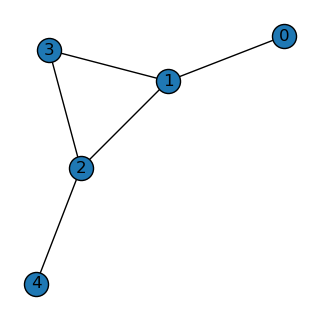

In [10]:
G = nx.Graph()

G.add_nodes_from([0,3,1,2,4])
G.add_edges_from([(0,1),(1,3),(2,3),(2,1),(4,2)]) # Agregamos nodos y aristas de manera que nos quede una red conexa

plt.figure(figsize=[3,3])
nx.draw_kamada_kawai(G, with_labels=True, edgecolors='k')

Analiza primero qué pasa paso a paso (con $t=1$) y después con una cantidad grande de iteraciones

(0.5, 113.5)

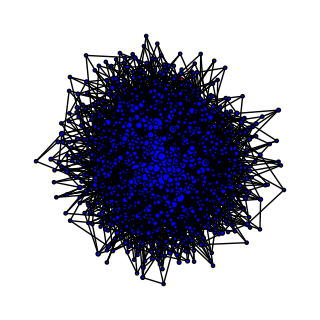

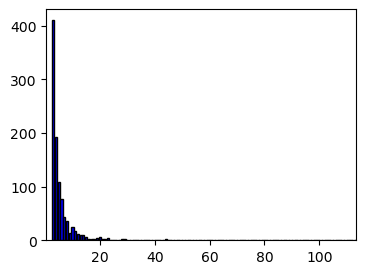

In [11]:
m=3 #Cantidad de nodos a los que se une el nuevo
t=1000 #Cantidad de iteraciones
for i in range(t):
    P = np.array([G.degree(nodo) for nodo in G])
    P = P/P.sum() # Se calcula la probabilidad de que un nodo viejo sea conectado con el nuevo nodo

    nuevo_nodo = len(G) #Definimos el nuevo nodo
    viejos_nodos = np.random.choice(G, replace = False, p = P, size=m) #Se seleccionan los nodos a conectar
    for viejo_nodo in viejos_nodos:
        G.add_edge(nuevo_nodo,viejo_nodo) #Se conectan el nodo nuevo con los viejos

colores = ['b' for nodo in G] #Construimos una cadena de colores azules para todos los nodos
colores[-1]='r' #Redefinimos el color el último nodo como rojo

grados = [G.degree(nodo) for nodo in G]
grados = np.array(grados) #Hacemos un arreglo de grados para 

plt.figure(figsize=[3,3])
nx.draw(G, edgecolors='k', node_color=colores, node_size=200*grados/grados.max()) #Normalizamos el tamaño de los nodos


y, x = np.histogram(grados, bins = range(m,max(grados)+2))

plt.figure(figsize = [4,3])
plt.bar(x[:-1], y, color = 'blue', edgecolor='k')
plt.xlim([.5,max(grados)+.5])

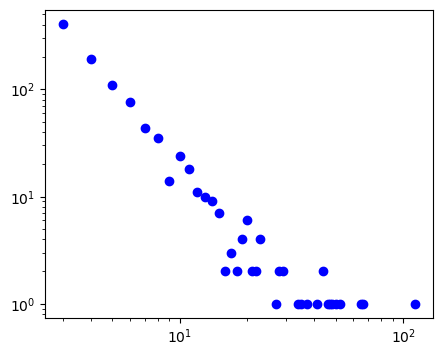

In [12]:
plt.figure(figsize = [5,4])
plt.loglog(x[:-1], y, 'o', color = 'blue')

In [13]:
saltos = []

for i in range(len(y)-1):
    if y[i+1] == 0 or y[i]==0 or y[i+1] == 1 :
        saltos.append(0)
    else:
        saltos.append(np.log(y[i]) / np.log(y[i+1]))
        print(y[i], y[i+1], np.log(y[i]) / np.log(y[i+1]))

410 193 1.1431714472537204
193 109 1.1217863865606708
109 77 1.0800087542197385
77 44 1.1478825962947266
44 35 1.064365448465538
35 14 1.3472037994747688
14 24 0.8304004496130023
24 18 1.0995311664203287
18 11 1.2053786463005403
11 10 1.041392685158225
10 9 1.0479516371446924
9 7 1.1291500681071593
7 2 2.807354922057604
2 3 0.6309297535714574
3 2 1.5849625007211563
2 4 0.5
4 6 0.7737056144690831
6 2 2.584962500721156
2 2 1.0
2 4 0.5
1 2 0.0
2 2 1.0


In [14]:

grados = np.array([G.degree(nodo) for nodo in G])

k_vals, n_k = np.unique(grados, return_counts=True)
p_k = n_k / n_k.sum()

#    log P(K=k) = log C - alpha log k

tail = k_vals >= 1

log_k = np.log(k_vals[tail])
log_p = np.log(p_k[tail])

pendiente, intercepto = np.polyfit(log_k, log_p, 1)

alpha_hat = -pendiente
C_hat = np.exp(intercepto)

print(f"Estimación de alpha: {alpha_hat:.4f}")
print(f"Estimación de C: {C_hat:.4f}")


Estimación de alpha: 1.8784
Estimación de C: 1.2957


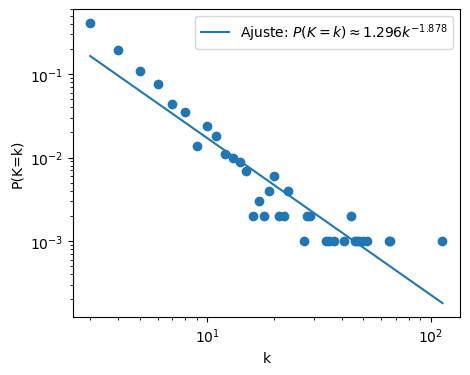

In [15]:
plt.figure(figsize=(5, 4))
plt.scatter(k_vals[tail], p_k[tail])
plt.plot(
    k_vals[tail],
    C_hat * k_vals[tail] ** (-alpha_hat),
    label=fr'Ajuste: $P(K=k)\approx {C_hat:.3f}k^{{-{alpha_hat:.3f}}}$'
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('k')
plt.ylabel('P(K=k)')
plt.legend()
plt.show()

Después de iterar una cantidad grande de veces, ¿la distribución de grados sigue una ley de potencias?
$$p_k=Ck^{-\alpha}$$
¿Cuál sería el valor de $\alpha$?

¿Qué pasa si se cambia la red inicial $G$? ¿Y con otro valor de $m$? Recuerda que $m$ no puede ser mayor que al cantidad de nodos de la red inicial.

El valor de $\alpha$ sigue siendo 3, imagino que cambiaria la constante $C$ de la ley de potencias.

### Distribución de grados

Analicemos la distribución de grados de una red con una gran cantidad de nodos.

In [16]:
from tqdm import tqdm

In [ ]:
G = nx.Graph()

G.add_nodes_from([0,3,1,2,4])
G.add_edges_from([(0,1),(1,3),(2,3),(2,1),(4,2)])

También puedes usar la función nx.barabasi_albert_graph de NetworkX: https://networkx.org/documentation/stable/reference/generated/networkx.generators.random_graphs.barabasi_albert_graph.html#networkx.generators.random_graphs.barabasi_albert_graph

(0.5, 91.5)

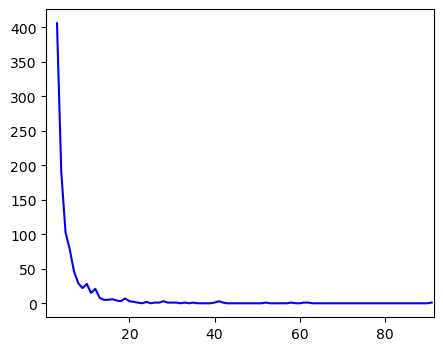

In [18]:
m=3 #Cantidad de nodos a los que se une el nuevo
t=1000 #Cantidad de iteraciones
for i in range(t):
    P = np.array([G.degree(nodo) for nodo in G])
    P = P/P.sum() # Se calcula la probabilidad de que un nodo viejo sea conectado con el nuevo nodo

    nuevo_nodo = len(G) #Definimos el nuevo nodo
    viejos_nodos = np.random.choice(G, replace = False, p = P, size=m) #Se seleccionan los nodos a conectar
    for viejo_nodo in viejos_nodos:
        G.add_edge(nuevo_nodo,viejo_nodo) #Se conectan el nodo nuevo con los viejos

grados = [G.degree(nodo) for nodo in G]
grados = np.array(grados) #Hacemos un arreglo de grados para 



y, x = np.histogram(grados, bins = range(m, max(grados)+2))

plt.figure(figsize = [5,4])
plt.plot(x[:-1], y, color = 'blue')
plt.xlim([.5,max(grados)+.5])

Cambia los valores de $C$ y $\alpha$ para encontrar la función $p_k=Ck^{\alpha}$ que mejor ajusta a la distribución de grados (visualizada en escala logarítmica). Prueba con distintas redes iniciales $G$, distintos valores de $m$ y una cantidad grande de iteraciones $t$.

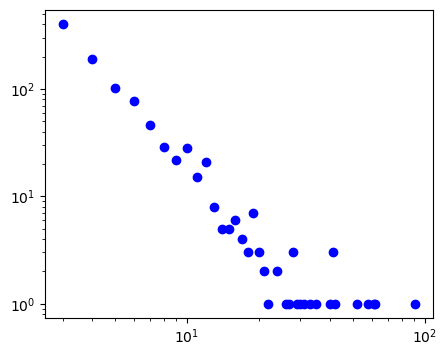

In [19]:
plt.figure(figsize = [5,4])
plt.loglog(x[:-1], y, 'o', color = 'blue')

In [20]:

grados = np.array([G.degree(nodo) for nodo in G])

k_vals, n_k = np.unique(grados, return_counts=True)
p_k = n_k / n_k.sum()

#    log P(K=k) = log C - alpha log k

tail = k_vals >= 1

log_k = np.log(k_vals[tail])
log_p = np.log(p_k[tail])

pendiente, intercepto = np.polyfit(log_k, log_p, 1)

alpha_hat = -pendiente
C_hat = np.exp(intercepto)

print(f"Estimación de alpha: {alpha_hat:.4f}")
print(f"Estimación de C: {C_hat:.4f}")


Estimación de alpha: 1.9902
Estimación de C: 1.6700


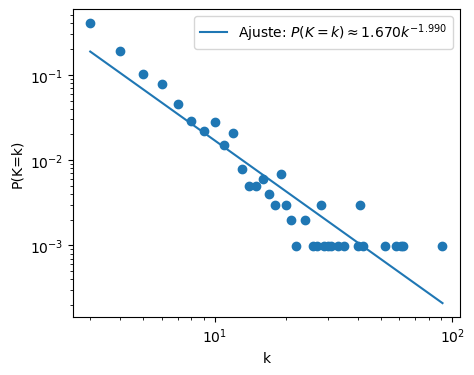

In [21]:
plt.figure(figsize=(5, 4))
plt.scatter(k_vals[tail], p_k[tail])
plt.plot(
    k_vals[tail],
    C_hat * k_vals[tail] ** (-alpha_hat),
    label=fr'Ajuste: $P(K=k)\approx {C_hat:.3f}k^{{-{alpha_hat:.3f}}}$'
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('k')
plt.ylabel('P(K=k)')
plt.legend()
plt.show()

También puedes usar la función nx.barabasi_albert_graph de NetworkX: https://networkx.org/documentation/stable/reference/generated/networkx.generators.random_graphs.barabasi_albert_graph.html#networkx.generators.random_graphs.barabasi_albert_graph

Cambia los valores de $C$ y $\alpha$ para encontrar la función $p_k=Ck^{\alpha}$ que mejor ajusta a la distribución de grados (visualizada en escala logarítmica). Prueba con distintas redes iniciales $G$, distintos valores de $m$ y una cantidad grande de iteraciones $t$.

In [29]:
def actividad():
    G = nx.Graph()

    G.add_nodes_from([0,3,1,2,4])
    G.add_edges_from([(0,1),(1,3),(2,3),(2,1),(4,2)])

    m=3 #Cantidad de nodos a los que se une el nuevo
    t=1000 #Cantidad de iteraciones
    for i in range(t):
        P = np.array([G.degree(nodo) for nodo in G])
        P = P/P.sum() # Se calcula la probabilidad de que un nodo viejo sea conectado con el nuevo nodo

        nuevo_nodo = len(G) #Definimos el nuevo nodo
        viejos_nodos = np.random.choice(G, replace = False, p = P, size=m) #Se seleccionan los nodos a conectar
        for viejo_nodo in viejos_nodos:
            G.add_edge(nuevo_nodo,viejo_nodo) #Se conectan el nodo nuevo con los viejos

    grados = [G.degree(nodo) for nodo in G]
    grados = np.array(grados) #Hacemos un arreglo de grados para 


    grados = np.array([G.degree(nodo) for nodo in G])

    k_vals, n_k = np.unique(grados, return_counts=True)
    p_k = n_k / n_k.sum()

    #    log P(K=k) = log C - alpha log k

    tail = k_vals >= 1

    log_k = np.log(k_vals[tail])
    log_p = np.log(p_k[tail])

    pendiente, intercepto = np.polyfit(log_k, log_p, 1)

    alpha_hat = -pendiente
    C_hat = np.exp(intercepto)

    print(f"Estimación de alpha: {alpha_hat:.4f}")
    print(f"Estimación de C: {C_hat:.4f}")

    plt.figure(figsize=(5, 4))
    plt.scatter(k_vals[tail], p_k[tail])
    plt.plot(
        k_vals[tail],
        C_hat * k_vals[tail] ** (-alpha_hat),
        label=fr'Ajuste: $P(K=k)\approx {C_hat:.3f}k^{{-{alpha_hat:.3f}}}$'
    )
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('k')
    plt.ylabel('P(K=k)')
    plt.legend()
    plt.show()


Estimación de alpha: 1.4499
Estimación de C: 0.3338


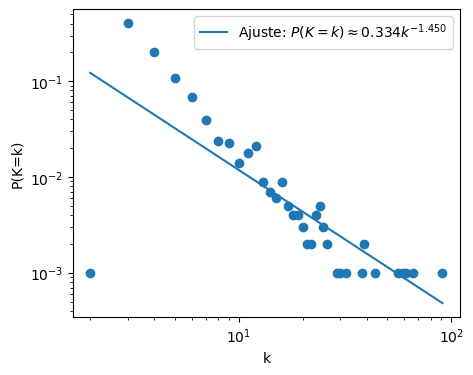

In [30]:
actividad()

Estimación de alpha: 1.7849
Estimación de C: 0.9701


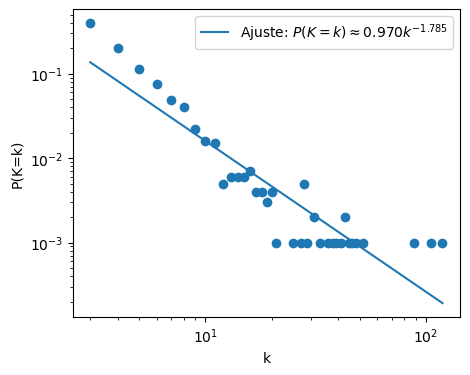

In [31]:
actividad()

Estimación de alpha: 1.9301
Estimación de C: 1.3039


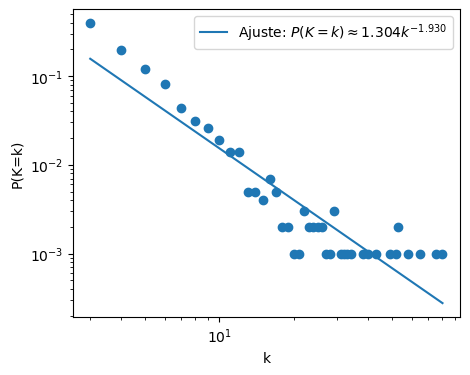

In [32]:
actividad()

Estimación de alpha: 1.9549
Estimación de C: 1.6053


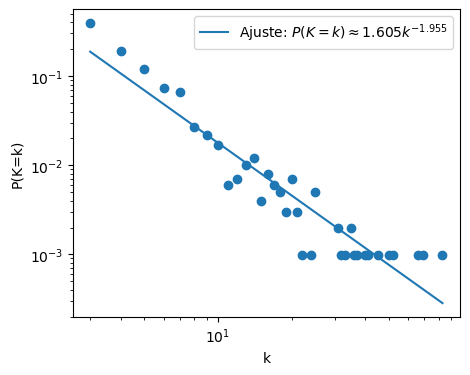

In [33]:
actividad()

Estimación de alpha: 2.0157
Estimación de C: 1.7547


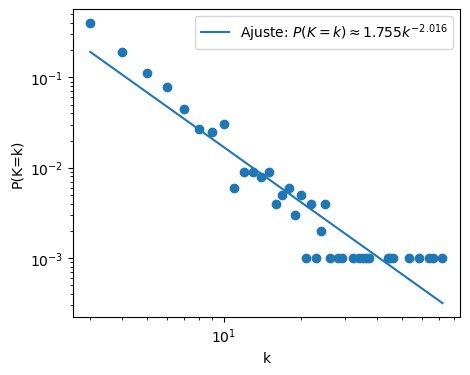

In [34]:
actividad()

Estimación de alpha: 2.0257
Estimación de C: 1.8043


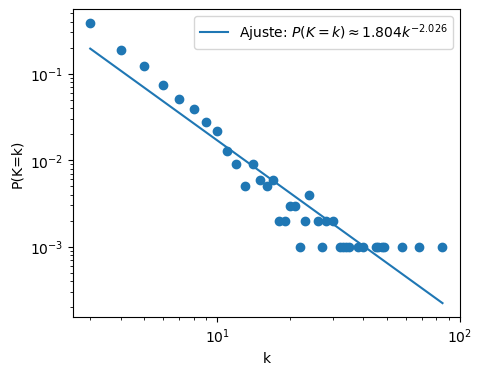

In [35]:
actividad()